In [1]:
!pip install ultralytics>=8.2 ensemble-boxes seaborn PyYAML tqdm pandas -q
!git clone https://github.com/ultralytics/yolov5 --quiet 2>/dev/null || true
!pip install -r yolov5/requirements.txt -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 7.3 MB/s eta 0:00:00


In [2]:
from google.colab import files
files.upload()   # select run_visdrone_ensemble.py from your Downloads

Saving run_visdrone_ensemble.py to run_visdrone_ensemble (1).py


{'run_visdrone_ensemble (1).py': b'"""\n=============================================================================\n  YOLOv5 + YOLOv8 + Ensemble Learning on VisDrone\n  Google Colab \xe2\x80\x93 COMPLETE RUNNABLE SCRIPT (Fixed Download)\n=============================================================================\nPASTE EACH CELL INTO SEPARATE COLAB CELLS AND RUN IN ORDER\n=============================================================================\n"""\n\n# =============================================================================\n# CELL 1 \xe2\x80\x94 Install dependencies\n# =============================================================================\n# !pip install ultralytics>=8.2 ensemble-boxes seaborn PyYAML tqdm pandas -q\n# !git clone https://github.com/ultralytics/yolov5 --quiet 2>/dev/null || echo "already cloned"\n# !pip install -r yolov5/requirements.txt -q\n# print("\xe2\x9c\x93 All installed")\n\n\n# ==============================================================

In [3]:
!python run_visdrone_ensemble.py

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
  YOLOv5 + YOLOv8 + Ensemble  |  VisDrone  |  Colab
  Device         : cuda
  Max train imgs : 500
  Epochs         : V5=30  V8=30
[i] Dataset not found → downloading …
[→] Downloading VisDrone2019-DET-train …
/content/VisDrone/V 100%[===================>]   1.44G   105MB/s    in 16s     
[→] Extracting VisDrone2019-DET-train …
[✓] VisDrone2019-DET-train ready
[→] Downloading VisDrone2019-DET-val …
/content/VisDrone/V 100%[===================>]  77.86M   121MB/s    in 0.6s    
[→] Extracting VisDrone2019-DET-val …
[✓] VisDrone2019-DET-val ready
[→] Converting VisDrone2019-DET-train (6471 files) …
  VisDrone2019-DET-train: 100% 6471/6471 [00:02<00:00, 2477.80it/s]
[✓] VisDrone2019-

In [8]:
# Check both models completed
import pandas as pd
from pathlib import Path

for model, run in [("YOLOv5", "yolov5s_visdrone"), ("YOLOv8", "yolov8n_visdrone")]:
    csv = Path(f"/content/runs/visdrone/{run}/results.csv")
    if csv.exists():
        df = pd.read_csv(csv); df.columns = df.columns.str.strip()
        last = df.iloc[-1]
        print(f"{'='*45}")
        print(f"  {model} Results")
        print(f"{'='*45}")

        if model == "YOLOv5":
            map50_key = 'metrics/mAP_0.5'
            map50_95_key = 'metrics/mAP_0.5:0.95'
        elif model == "YOLOv8":
            map50_key = 'metrics/mAP50(B)'
            map50_95_key = 'metrics/mAP50-95(B)'
        else:
            print(f"  [!] Unknown model type: {model}")
            continue

        print(f"  mAP@0.5     : {last[map50_key]:.4f}")
        print(f"  mAP@0.5:0.95: {last[map50_95_key]:.4f}")
    else:
        print(f"[!] {model} results not found at {csv}")

  YOLOv5 Results
  mAP@0.5     : 0.1314
  mAP@0.5:0.95: 0.0624
  YOLOv8 Results
  mAP@0.5     : 0.1731
  mAP@0.5:0.95: 0.0970


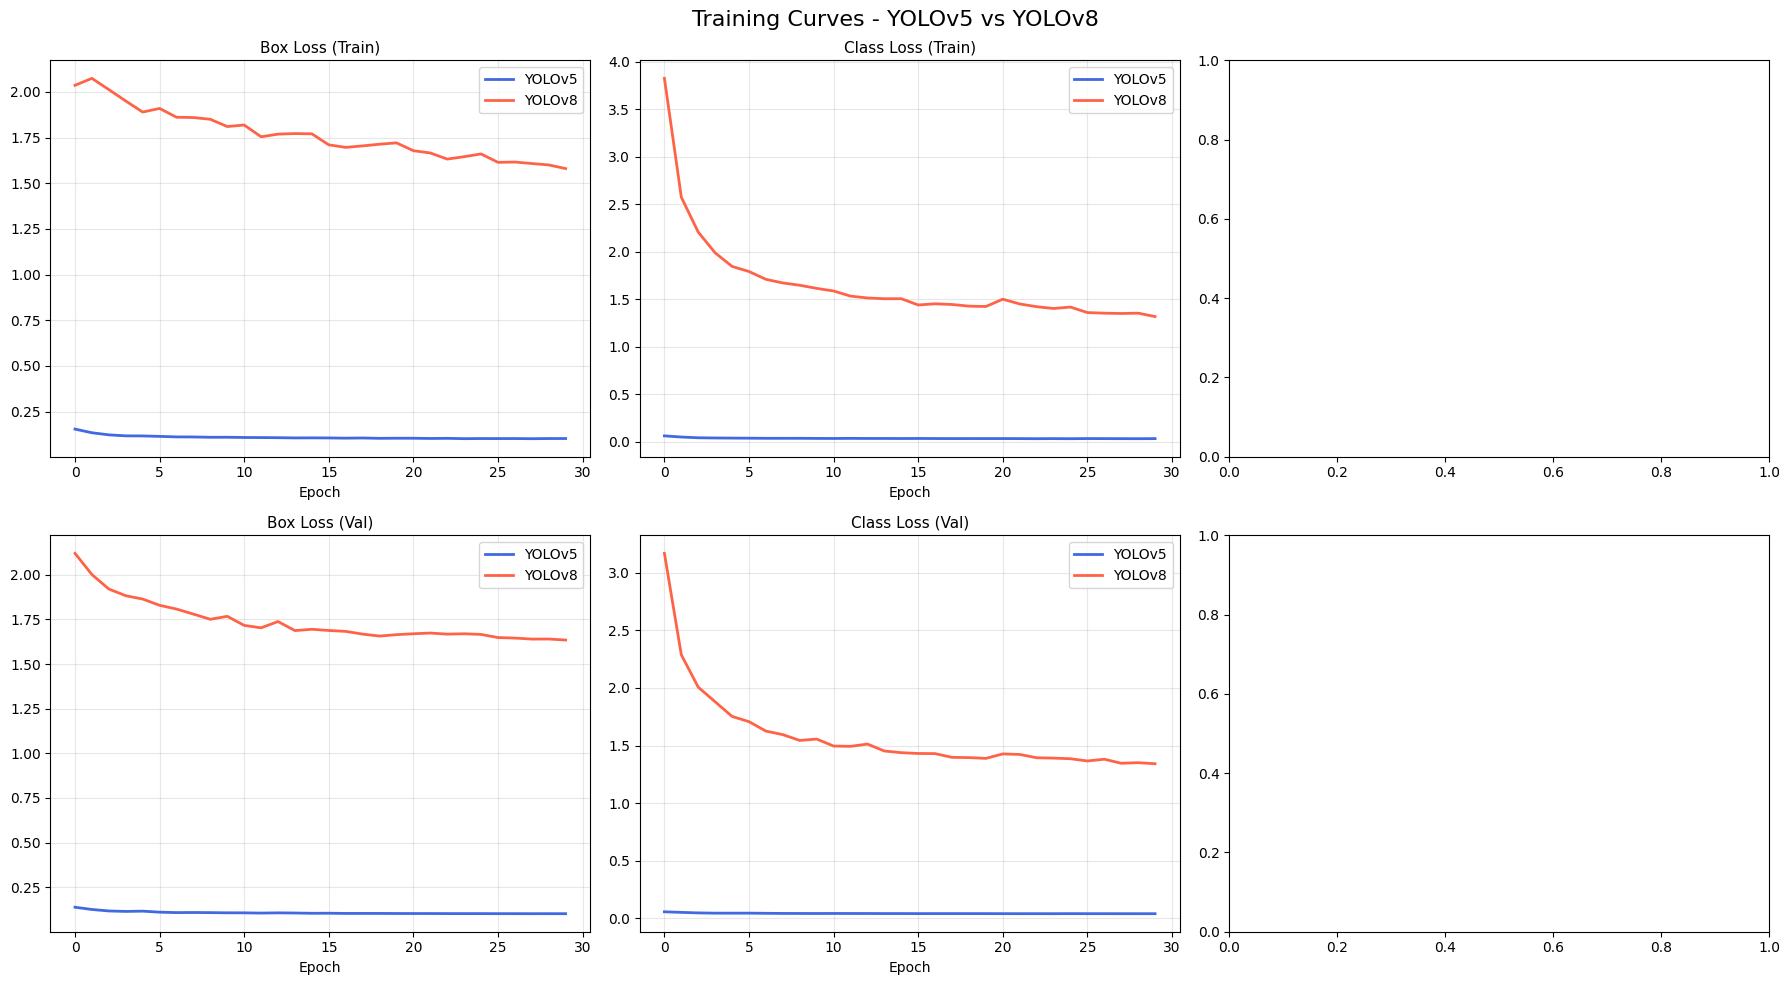

✓ Training curves saved


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path("/content/runs/visdrone")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Training Curves - YOLOv5 vs YOLOv8", fontsize=16)

metric_map = {
    "train/box_loss":   ("Box Loss (Train)",    0, 0),
    "train/cls_loss":   ("Class Loss (Train)",  0, 1),
    "metrics/mAP50":    ("mAP@0.5 (Val)",       0, 2),
    "val/box_loss":     ("Box Loss (Val)",       1, 0),
    "val/cls_loss":     ("Class Loss (Val)",     1, 1),
    "metrics/mAP50-95": ("mAP@0.5:0.95 (Val)",  1, 2),
}

for label, (run_name, color) in {
    "YOLOv5": ("yolov5s_visdrone", "royalblue"),
    "YOLOv8": ("yolov8n_visdrone", "tomato"),
}.items():
    csv = PROJECT_DIR / run_name / "results.csv"
    if not csv.exists():
        print(f"[!] {csv} not found - skipping {label}")
        continue
    df = pd.read_csv(csv)
    df.columns = df.columns.str.strip()
    for col, (title, ri, ci) in metric_map.items():
        if col in df.columns:
            axes[ri][ci].plot(df[col], label=label, color=color, lw=2)
            axes[ri][ci].set_title(title, fontsize=11)
            axes[ri][ci].set_xlabel("Epoch")
            axes[ri][ci].legend()
            axes[ri][ci].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/runs/visdrone/training_curves.png", dpi=150)
plt.show()
print("✓ Training curves saved")

In [10]:
import os, subprocess, tempfile
import numpy as np
from pathlib import Path
from PIL import Image
from ultralytics import YOLO
from ensemble_boxes import weighted_boxes_fusion, nms, soft_nms

os.environ["WANDB_DISABLED"] = "true"

CLASSES = ["pedestrian","people","bicycle","car","van",
           "truck","tricycle","awning-tricycle","bus","motor"]
NC = len(CLASSES)

V5_WEIGHTS = Path("/content/runs/visdrone/yolov5s_visdrone/weights/best.pt")
V8_WEIGHTS = Path("/content/runs/visdrone/yolov8n_visdrone/weights/best.pt")

print(f"YOLOv5 weights found: {V5_WEIGHTS.exists()}")
print(f"YOLOv8 weights found: {V8_WEIGHTS.exists()}")

def yolov5_predict(img_path, conf=0.01, iou=0.6):
    td  = Path(tempfile.mkdtemp())
    cmd = (f"python yolov5/detect.py --weights {V5_WEIGHTS} "
           f"--source {img_path} --conf-thres {conf} --iou-thres {iou} "
           f"--imgsz 640 --device cpu "
           f"--project {td} --name p --exist-ok "
           f"--save-txt --save-conf --nosave")
    subprocess.run(cmd.split(), capture_output=True)
    lf = td/"p"/"labels"/(Path(img_path).stem+".txt")
    if not lf.exists() or lf.stat().st_size == 0:
        return np.zeros((0,4)), np.zeros(0), np.zeros(0,dtype=int)
    data = np.loadtxt(lf)
    if data.ndim == 1: data = data[None]
    img  = np.array(Image.open(img_path))
    H, W = img.shape[:2]
    cx,cy,bw,bh = data[:,1],data[:,2],data[:,3],data[:,4]
    boxes = np.stack([(cx-bw/2)*W,(cy-bh/2)*H,
                       (cx+bw/2)*W,(cy+bh/2)*H], axis=1)
    return boxes, data[:,5], data[:,0].astype(int)

def yolov8_predict(img_path, conf=0.01, iou=0.6):
    res = YOLO(str(V8_WEIGHTS)).predict(
        img_path, conf=conf, iou=iou, imgsz=640, verbose=False)
    if not res or res[0].boxes is None or len(res[0].boxes)==0:
        return np.zeros((0,4)), np.zeros(0), np.zeros(0,dtype=int)
    return (res[0].boxes.xyxy.cpu().numpy(),
            res[0].boxes.conf.cpu().numpy(),
            res[0].boxes.cls.cpu().numpy().astype(int))

def ensemble_predict(img_path, method="wbf", conf_thr=0.25, iou_thr=0.5):
    img  = np.array(Image.open(img_path).convert("RGB"))
    H, W = img.shape[:2]
    b5,s5,l5 = yolov5_predict(img_path)
    b8,s8,l8 = yolov8_predict(img_path)

    def norm(b):
        if len(b)==0: return []
        b=b.copy().astype(float)
        b[:,[0,2]]/=W; b[:,[1,3]]/=H
        return np.clip(b,0,1).tolist()

    BL=[norm(b5),norm(b8)]; SL=[s5.tolist(),s8.tolist()]; LL=[l5.tolist(),l8.tolist()]

    if method=="wbf":
        boxes,scores,labels=weighted_boxes_fusion(BL,SL,LL,weights=[0.45,0.55],
                             iou_thr=iou_thr,skip_box_thr=conf_thr)
    elif method=="nms":
        boxes,scores,labels=nms(BL,SL,LL,weights=[0.45,0.55],iou_thr=iou_thr)
    elif method=="soft_nms":
        boxes,scores,labels=soft_nms(BL,SL,LL,weights=[0.45,0.55],
                            iou_thr=iou_thr,sigma=0.5)

    mask=scores>=conf_thr
    boxes=np.array(boxes[mask])
    if len(boxes):
        boxes[:,[0,2]]*=W; boxes[:,[1,3]]*=H
    return boxes, scores[mask], labels[mask].astype(int), img

print("✓ Ensemble functions ready!")

YOLOv5 weights found: True
YOLOv8 weights found: True
✓ Ensemble functions ready!


Using: /content/VisDrone/VisDrone2019-DET-val/images/0000001_03499_d_0000006.jpg


/tmp/ipython-input-945/2129419173.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  pal = plt.cm.get_cmap("tab20", NC)


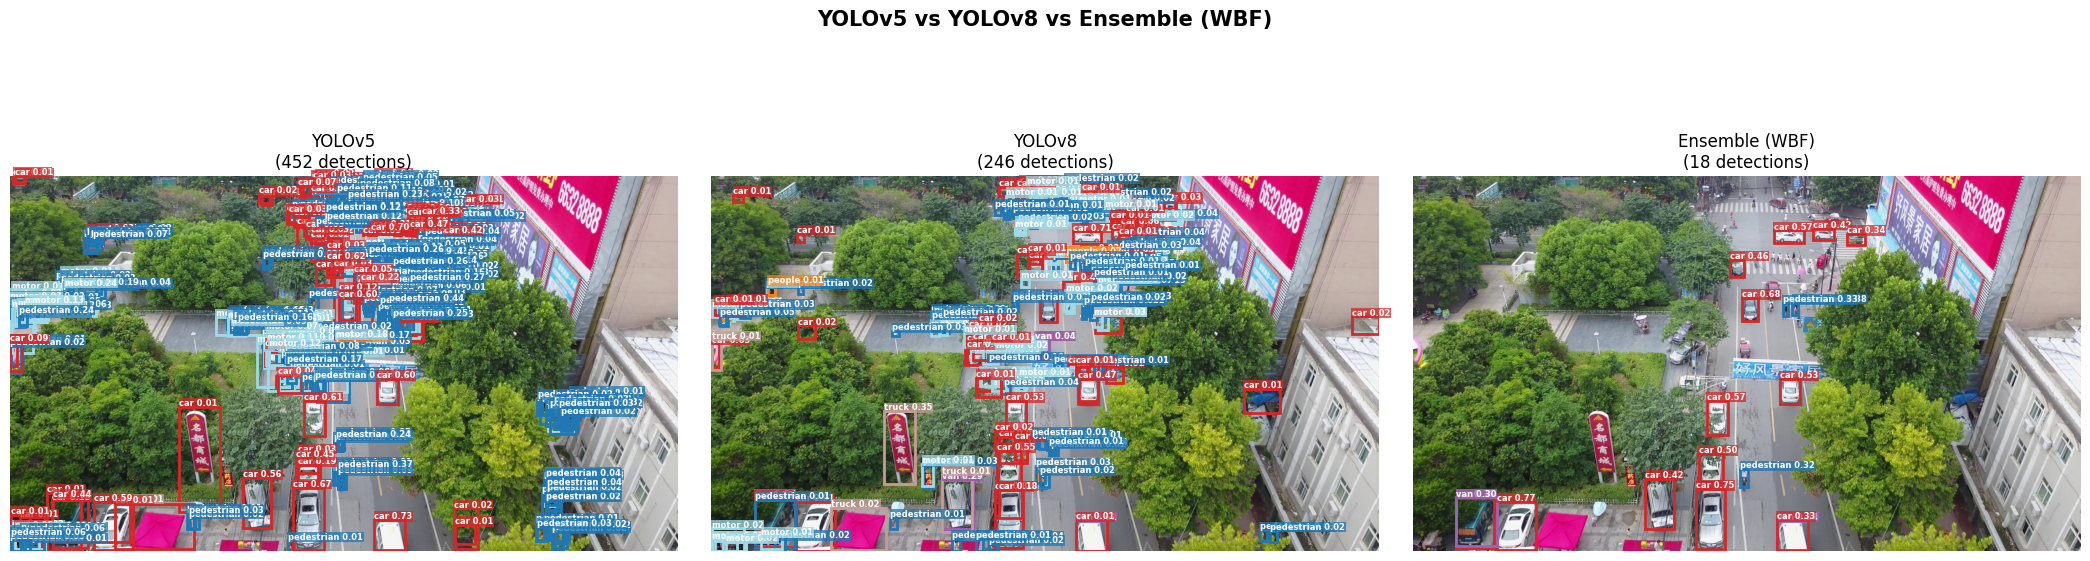

✓ Saved | V5=452  V8=246  Ensemble=18 detections


In [11]:
import glob, random
import matplotlib.pyplot as plt
import matplotlib.patches as patches

val_imgs = (glob.glob("/content/VisDrone_subset/val/images/*.jpg") +
            glob.glob("/content/VisDrone/VisDrone2019-DET-val/images/*.jpg"))

sample = random.choice(val_imgs)
print(f"Using: {sample}")

pal = plt.cm.get_cmap("tab20", NC)

def draw_boxes(ax, img, boxes, scores, labels, title):
    ax.imshow(img)
    for box,score,label in zip(boxes,scores,labels):
        x1,y1,x2,y2=box; c=pal(int(label))[:3]
        ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,
                     lw=2,edgecolor=c,facecolor="none"))
        name=CLASSES[int(label)] if int(label)<NC else str(label)
        ax.text(x1,y1-3,f"{name} {score:.2f}",color="white",fontsize=6,
                weight="bold",bbox=dict(facecolor=c,alpha=0.75,pad=0.5,edgecolor="none"))
    ax.set_title(f"{title}\n({len(boxes)} detections)",fontsize=12)
    ax.axis("off")

img_np     = np.array(Image.open(sample).convert("RGB"))
b5,s5,l5   = yolov5_predict(sample)
b8,s8,l8   = yolov8_predict(sample)
be,se,le,_ = ensemble_predict(sample, method="wbf")

fig, axes = plt.subplots(1, 3, figsize=(21,7))
draw_boxes(axes[0], img_np.copy(), b5, s5, l5, "YOLOv5")
draw_boxes(axes[1], img_np.copy(), b8, s8, l8, "YOLOv8")
draw_boxes(axes[2], img_np.copy(), be, se, le, "Ensemble (WBF)")

plt.suptitle("YOLOv5 vs YOLOv8 vs Ensemble (WBF)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/runs/visdrone/comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved | V5={len(b5)}  V8={len(b8)}  Ensemble={len(be)} detections")